In [1]:
import uproot as ur
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
from math import sin, cos
from podio.root_io import Reader

In [2]:
rf = ur.open('glassbar_cherenkov.root')

In [3]:
rf.keys()

['events;2', 'events;1', 'runs;1', 'meta;1', 'metadata;1', 'podio_metadata;1']

In [4]:
rf['events'].keys()

['EventHeader',
 'EventHeader/EventHeader.eventNumber',
 'EventHeader/EventHeader.runNumber',
 'EventHeader/EventHeader.timeStamp',
 'EventHeader/EventHeader.weight',
 'EventHeader/EventHeader.weights_begin',
 'EventHeader/EventHeader.weights_end',
 '_EventHeader_weights',
 'LeadGlassBarHits',
 'LeadGlassBarHits/LeadGlassBarHits.cellID',
 'LeadGlassBarHits/LeadGlassBarHits.eDep',
 'LeadGlassBarHits/LeadGlassBarHits.time',
 'LeadGlassBarHits/LeadGlassBarHits.pathLength',
 'LeadGlassBarHits/LeadGlassBarHits.quality',
 'LeadGlassBarHits/LeadGlassBarHits.position.x',
 'LeadGlassBarHits/LeadGlassBarHits.position.y',
 'LeadGlassBarHits/LeadGlassBarHits.position.z',
 'LeadGlassBarHits/LeadGlassBarHits.momentum.x',
 'LeadGlassBarHits/LeadGlassBarHits.momentum.y',
 'LeadGlassBarHits/LeadGlassBarHits.momentum.z',
 '_LeadGlassBarHits_particle',
 '_LeadGlassBarHits_particle/_LeadGlassBarHits_particle.index',
 '_LeadGlassBarHits_particle/_LeadGlassBarHits_particle.collectionID',
 'MCParticles',
 'M

In [5]:
rf['events']['SiPMHits'].keys()

['SiPMHits.cellID',
 'SiPMHits.eDep',
 'SiPMHits.time',
 'SiPMHits.pathLength',
 'SiPMHits.quality',
 'SiPMHits.position.x',
 'SiPMHits.position.y',
 'SiPMHits.position.z',
 'SiPMHits.momentum.x',
 'SiPMHits.momentum.y',
 'SiPMHits.momentum.z']

In [121]:
def run_simulation(phi: float, n_events: int, output_name: str, store_photon_steps: bool = False):
    """Run ddsim for n_events with the gun direction tilted to
    (0, sin(phi), cos(phi)) (phi in radians, matching the convention above),
    writing output to output_name.

    store_photon_steps=True passes --storePhotonSteps through to
    steering.py, switching LeadGlassBar to one hit per Geant4 step (every
    TIR bounce/refraction included) instead of one combined hit per
    particle. Needed for true per-bounce polylines in the event display,
    but multiplies hit count/output size/runtime a lot -- keep n_events
    small (a handful) when using it.

    Runs in a subprocess with a minimal, explicit environment (not this
    notebook kernel's os.environ) before sourcing setup.sh, so the
    kernel's already-sourced key4hep stack can't leak in and conflict
    with the one setup.sh resolves fresh. Streams ddsim's output live and
    raises if it fails.
    """
    import subprocess
    import shlex
    import os

    direction = (0, round(sin(phi), 7), round(cos(phi), 7))

    # Minimal starting environment: just enough for bash/source/basic
    # tools to work. Everything else (LD_LIBRARY_PATH, PYTHONPATH,
    # ROOT_INCLUDE_PATH, etc.) comes fresh from `source setup.sh` inside
    # the subprocess, not inherited from this kernel's own environment.
    clean_env = {
        "PATH": "/usr/bin:/bin",
        "HOME": os.environ.get("HOME", "/tmp"),
        "USER": os.environ.get("USER", ""),
        "TERM": os.environ.get("TERM", "xterm"),
    }

    cmd = (
        "source setup.sh && "
        "ddsim --steeringFile steering.py "
        f"-N {int(n_events)} "
        f"--outputFile {shlex.quote(output_name)} "
        f'--gun.direction "{direction[0]},{direction[1]},{direction[2]}"'
    )
    if store_photon_steps:
        cmd += " --storePhotonSteps"

    proc = subprocess.Popen(
        cmd,
        shell=True,
        executable="/bin/bash",
        env=clean_env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )
    for line in proc.stdout:
        print(line, end="")
    proc.wait()

    if proc.returncode != 0:
        raise RuntimeError(f"ddsim failed (exit {proc.returncode}) for phi={phi}, output={output_name}")

    return proc

In [ ]:
from math import pi

with_photon_steps = True

for phi_deg in [35, 40, 45]: # [1, 3, 5, 7]:# [10, 20, 30, 40, 50]:
    run_simulation(phi_deg * pi / 180, 100, f'glassbar_cherenkov_{phi_deg}_steps.root' if with_photon_steps else f'glassbar_cherenkov_{phi_deg}.root', with_photon_steps)

In [122]:
phi_deg_read = 40

rf = ur.open(f'glassbar_cherenkov_{phi_deg_read}_steps.root' if with_photon_steps else f'glassbar_cherenkov_{phi_deg_read}.root')

In [137]:
N_BINS = 50
SIPM_HIST_HALF = 47.5  # mm, SiPM active-area half-width (compact/GlassBar/GlassBar_Cherenkov.xml)

hist_total = np.zeros((N_BINS, N_BINS))

In [138]:
for event_idx in range(100):
    posX = np.array(rf['events']['SiPMHits/SiPMHits.position.x'].array()[event_idx])
    posY = np.array(rf['events']['SiPMHits/SiPMHits.position.y'].array()[event_idx])
    posZ = np.array(rf['events']['SiPMHits/SiPMHits.position.z'].array()[event_idx])

    # range must be fixed and shared across events -- without it np.histogram2d
    # auto-picks bin edges from *this event's own* min/max, so summing hist[0]
    # across events adds histograms whose bins don't correspond to the same
    # physical (x,y) region at all, turning any real spatial structure into
    # noise. This was silently wrong before (verified: fixing it collapses a
    # near-uniform noise pattern into a sharp blob at the bar's footprint).
    hist = np.histogram2d(posX, posY, bins=(N_BINS, N_BINS),
                           range=[[-SIPM_HIST_HALF, SIPM_HIST_HALF], [-SIPM_HIST_HALF, SIPM_HIST_HALF]])
    hist_total += hist[0]

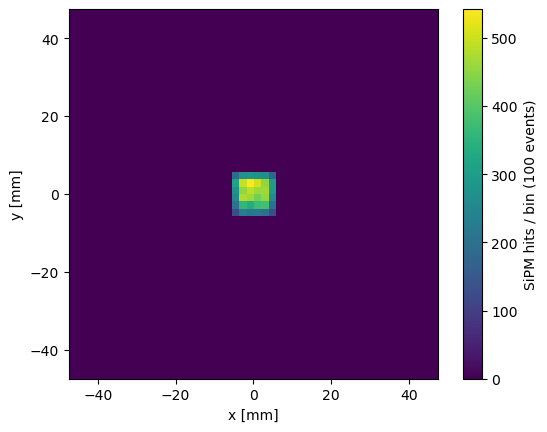

In [139]:
fig, ax = plt.subplots()
# .T + origin='lower': imshow's first axis is rows (=y in histogram2d's
# output), and by default row 0 is drawn at the top -- transpose and flip
# so the image matches the usual x-right/y-up SiPM-plane orientation.
im = ax.imshow(hist_total.T, origin='lower',
                extent=[-SIPM_HIST_HALF, SIPM_HIST_HALF, -SIPM_HIST_HALF, SIPM_HIST_HALF])
ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
fig.colorbar(im, label='SiPM hits / bin (100 events)')

## Event display: electron passage + Cherenkov photon paths

Truth-level positions only (no per-step trajectories are stored): the electron's `MCParticles` vertex/endpoint gives its start/true-stop point, and each Cherenkov photon (`PDG == -22`) that survives the ParticleHandler's cuts has its own vertex (emission point in the glass) and endpoint (where it was absorbed/left the tracked region). Photon paths are drawn as straight vertex&rarr;endpoint chords, so any TIR bounces inside the bar are invisible here — a fine simplification for a "best case, stacked events" overview, not a faithful ray trace.

In [126]:
# Detector dimensions (mm) from compact/GlassBar/GlassBar_Cherenkov.xml
BAR_HALF_X, BAR_HALF_Y, BAR_Z0, BAR_Z1 = 5.0, 5.0, 0.0, 500.0
SIPM_HALF_X, SIPM_HALF_Y, SIPM_Z0, SIPM_Z1 = 47.5, 47.5, 500.0, 502.0

N_EVENTS_DISPLAY = 6
N_PHOTONS_PER_EVENT = 120
Z_VIEW_MAX = 520.0  # mm; the primary electron's true endpoint is ~metres downstream
                     # in open air/vacuum once it exits the bar, so redraw its segment
                     # ending here instead of swamping the plot scale.

rng = np.random.default_rng(0)


def _clip_to_zmax(v, e, z_max=Z_VIEW_MAX):
    v, e = np.asarray(v, dtype=float), np.asarray(e, dtype=float)
    if e[2] <= z_max:
        return e
    t = (z_max - v[2]) / (e[2] - v[2])
    return v + t * (e - v)

In [127]:
mcp = rf['events']['MCParticles']
pdg = mcp['MCParticles.PDG'].array()
gstat = mcp['MCParticles.generatorStatus'].array()
pbeg = mcp['MCParticles.parents_begin'].array()
pend = mcp['MCParticles.parents_end'].array()
vx, vy, vz = (mcp[f'MCParticles.vertex.{c}'].array() for c in 'xyz')
ex, ey, ez = (mcp[f'MCParticles.endpoint.{c}'].array() for c in 'xyz')

electron_segments = []  # [(vertex_xyz, clipped_endpoint_xyz), ...] one per event
photon_segments = []    # same, pooled/sampled across events

for i in range(N_EVENTS_DISPLAY):
    p = ak.to_numpy(pdg[i])
    primary_mask = (ak.to_numpy(pbeg[i]) == ak.to_numpy(pend[i])) & (ak.to_numpy(gstat[i]) == 1)
    e_idx = np.nonzero(primary_mask)[0][0]
    v = np.array([vx[i][e_idx], vy[i][e_idx], vz[i][e_idx]])
    e = np.array([ex[i][e_idx], ey[i][e_idx], ez[i][e_idx]])
    electron_segments.append((v, _clip_to_zmax(v, e)))

    ph_idx = np.nonzero(p == -22)[0]
    if len(ph_idx) > N_PHOTONS_PER_EVENT:
        ph_idx = rng.choice(ph_idx, size=N_PHOTONS_PER_EVENT, replace=False)
    for j in ph_idx:
        v = np.array([vx[i][j], vy[i][j], vz[i][j]])
        e = np.array([ex[i][j], ey[i][j], ez[i][j]])
        photon_segments.append((v, _clip_to_zmax(v, e)))

print(f'{len(electron_segments)} electron tracks, {len(photon_segments)} sampled photon tracks')

6 electron tracks, 720 sampled photon tracks


Text(0.5, 1.0, '6 events, phi=40deg: electron passage (red) + 120/event sampled Cherenkov photons (blue)')

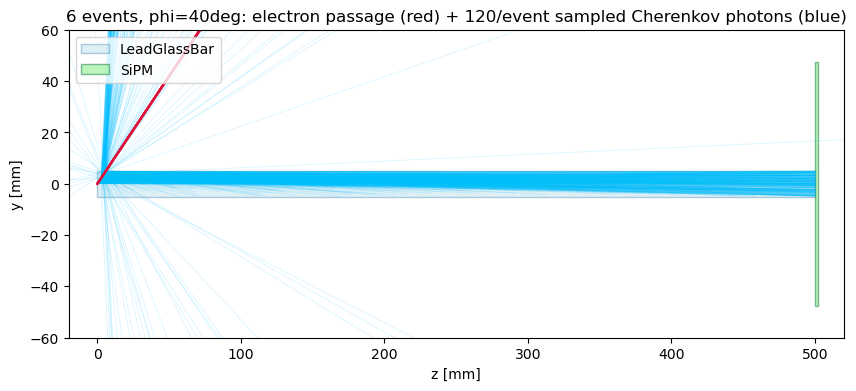

In [128]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.add_patch(plt.Rectangle((BAR_Z0, -BAR_HALF_Y), BAR_Z1 - BAR_Z0, 2 * BAR_HALF_Y,
                            facecolor='lightblue', edgecolor='steelblue', alpha=0.4, label='LeadGlassBar'))
ax.add_patch(plt.Rectangle((SIPM_Z0, -SIPM_HALF_Y), SIPM_Z1 - SIPM_Z0, 2 * SIPM_HALF_Y,
                            facecolor='lightgreen', edgecolor='seagreen', alpha=0.6, label='SiPM'))

for v, e in photon_segments:
    ax.plot([v[2], e[2]], [v[1], e[1]], color='deepskyblue', alpha=0.15, linewidth=0.6)

for v, e in electron_segments:
    ax.plot([v[2], e[2]], [v[1], e[1]], color='crimson', linewidth=1.5)

ax.set_xlabel('z [mm]')
ax.set_ylabel('y [mm]')
ax.set_xlim(-20, Z_VIEW_MAX)
ax.set_ylim(-60, 60)
ax.legend(loc='upper left')
ax.set_title(f'{N_EVENTS_DISPLAY} events, phi={phi_deg_read}deg: electron passage (red) '
             f'+ {N_PHOTONS_PER_EVENT}/event sampled Cherenkov photons (blue)')

Text(0.5, 0.92, '6 events, phi=40deg')

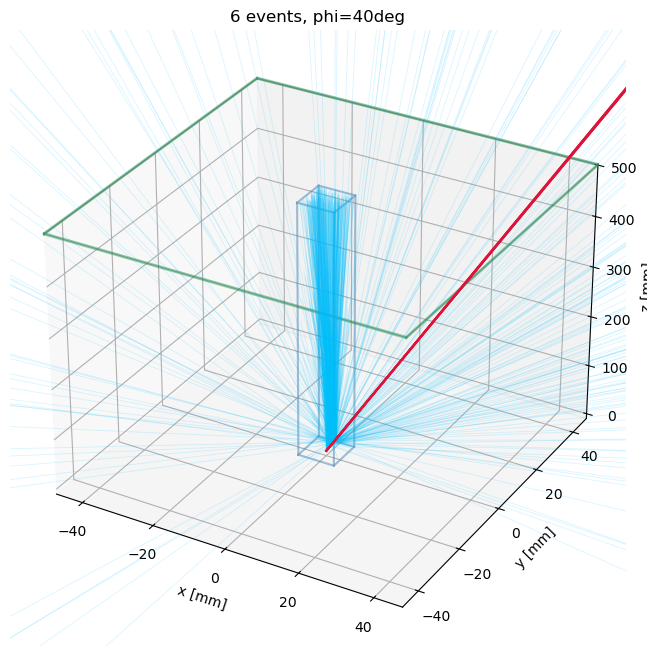

In [129]:
def _plot_box(ax, xh, yh, z0, z1, color):
    for zz in (z0, z1):
        ax.plot([-xh, xh, xh, -xh, -xh], [-yh, -yh, yh, yh, -yh], zz, color=color, alpha=0.5)
    for x_ in (-xh, xh):
        for y_ in (-yh, yh):
            ax.plot([x_, x_], [y_, y_], [z0, z1], color=color, alpha=0.5)


fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

_plot_box(ax, BAR_HALF_X, BAR_HALF_Y, BAR_Z0, BAR_Z1, 'steelblue')
_plot_box(ax, SIPM_HALF_X, SIPM_HALF_Y, SIPM_Z0, SIPM_Z1, 'seagreen')

for v, e in photon_segments:
    ax.plot([v[0], e[0]], [v[1], e[1]], [v[2], e[2]], color='deepskyblue', alpha=0.15, linewidth=0.6)

for v, e in electron_segments:
    ax.plot([v[0], e[0]], [v[1], e[1]], [v[2], e[2]], color='crimson', linewidth=1.5)

ax.set_xlim(-SIPM_HALF_X, SIPM_HALF_X)
ax.set_ylim(-SIPM_HALF_Y, SIPM_HALF_Y)
ax.set_zlim(-10, SIPM_Z1)

ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
ax.set_zlabel('z [mm]')
ax.set_title(f'{N_EVENTS_DISPLAY} events, phi={phi_deg_read}deg')

## True per-bounce photon paths (`--storePhotonSteps`)

The chords above are a simplification: each drawn segment only connects a photon's *true* birth and death points, with any TIR bounces/refractions in between invisible. `steering.py`'s `--storePhotonSteps` flag switches `LeadGlassBar` to `EveryStepTrackerAction` (`plugins/src/EveryStepTrackerAction.cpp`) — a custom Geant4 sensitive action that records a hit on *every* step of *every* optical photon, regardless of energy deposit. Every built-in DDG4 tracker action only ever creates a hit when a step has nonzero deposit, and a TIR bounce or refraction is elastic (zero deposit), so they silently drop every bounce and only ever see a photon's single final absorption step. This action instead gives the real bounce-by-bounce polyline. The electron's dE/dx hits are unaffected (still deposit-gated, since ionization deposits at every step anyway).

It's off by default and meaningfully more expensive: an untreated-glass photon can realistically bounce hundreds of times before ABSLENGTH's statistical cutoff catches it, and recording every step of every photon in an event was measured to blow up to ~4.5GB RSS in under a minute. `MaxOpticalTracks`/`MaxHitsPerTrack` (set in `steering.py`) cap this to ~200 tracked photons/event, ~500 recorded bounces each — plenty for visualization, not a full-fidelity dump.

Generated with:
```
ddsim --steeringFile steering.py --storePhotonSteps -N 5 --gun.direction "0,0.1391731,0.9902681" --outputFile glassbar_cherenkov_8_steps.root
```

In [130]:
rf_steps = ur.open(f'glassbar_cherenkov_{phi_deg_read}_steps.root')

N_EVENTS_STEPS = 5  # matches the file above
N_PHOTONS_PER_EVENT_TRUE = 4  # each photon draws up to 500 points (MaxHitsPerTrack);
                               # unlike the chord plot above, a handful is plenty --
                               # more than ~10-20 total saturates into a solid block
                               # since bounces stay confined to the 10mm bar width.

mcp_s = rf_steps['events']['MCParticles']
pdg_s = mcp_s['MCParticles.PDG'].array()
gstat_s = mcp_s['MCParticles.generatorStatus'].array()
pbeg_s = mcp_s['MCParticles.parents_begin'].array()
pend_s = mcp_s['MCParticles.parents_end'].array()
ex_s, ey_s, ez_s = (mcp_s[f'MCParticles.endpoint.{c}'].array() for c in 'xyz')

lgb_s = rf_steps['events']['LeadGlassBarHits']
lgb_s_idx = rf_steps['events']['_LeadGlassBarHits_particle/_LeadGlassBarHits_particle.index'].array()
lgb_s_x, lgb_s_y, lgb_s_z = (lgb_s[f'LeadGlassBarHits.position.{c}'].array() for c in 'xyz')
lgb_s_t = lgb_s['LeadGlassBarHits.time'].array()


def _true_polyline(event_idx, particle_idx):
    """(N, 3) time-ordered hit positions for one particle in one event."""
    idx = ak.to_numpy(lgb_s_idx[event_idx])
    m = idx == particle_idx
    xs = ak.to_numpy(lgb_s_x[event_idx])[m]
    ys = ak.to_numpy(lgb_s_y[event_idx])[m]
    zs = ak.to_numpy(lgb_s_z[event_idx])[m]
    ts = ak.to_numpy(lgb_s_t[event_idx])[m]
    order = np.argsort(ts)
    return np.stack([xs[order], ys[order], zs[order]], axis=-1)


electron_polylines = []
photon_polylines = []

for i in range(N_EVENTS_STEPS):
    p = ak.to_numpy(pdg_s[i])
    primary_mask = (ak.to_numpy(pbeg_s[i]) == ak.to_numpy(pend_s[i])) & (ak.to_numpy(gstat_s[i]) == 1)
    e_idx = np.nonzero(primary_mask)[0][0]
    line = _true_polyline(i, e_idx)
    if len(line) > 0:
        # extend from the last recorded hit to Z_VIEW_MAX: the electron
        # travels undisturbed once it leaves the bar into open air, same
        # reasoning as the clipped chord in the section above.
        e_end = np.array([ex_s[i][e_idx], ey_s[i][e_idx], ez_s[i][e_idx]])
        tail = _clip_to_zmax(line[-1], e_end)
        electron_polylines.append(np.vstack([line, tail]))

    idx_arr = ak.to_numpy(lgb_s_idx[i])
    ph_idx = np.nonzero(p == -22)[0]
    tracked = np.intersect1d(np.unique(idx_arr), ph_idx)
    if len(tracked) > N_PHOTONS_PER_EVENT_TRUE:
        tracked = rng.choice(tracked, size=N_PHOTONS_PER_EVENT_TRUE, replace=False)
    for j in tracked:
        line = _true_polyline(i, j)
        if len(line) >= 2:
            photon_polylines.append(line)

# only show photons progressing towards SiPM (non which are reflected from the glass-SiPM-boundary)
if True:
    for i in range(len(photon_polylines)):
        mask_size = len(photon_polylines[i])
        mask = np.ones(mask_size, dtype=bool)

        z = photon_polylines[i][:, 2]
        z_shifted = np.zeros_like(z)
        z_shifted[1:] = z[:-1]

        z_smaller = z < z_shifted
        if z_smaller.sum():
            first_excluded = np.where(z_smaller)[0][0]
            mask[first_excluded:] = False

        print(f'Keeping {mask.sum()}/{len(mask)} ({mask.sum()/len(mask):.2%}) photon positions')
        photon_polylines[i] = photon_polylines[i][mask]

print(f'{len(electron_polylines)} electron polylines, {len(photon_polylines)} photon polylines')

Keeping 67/500 (13.40%) photon positions
Keeping 175/500 (35.00%) photon positions
Keeping 23/23 (100.00%) photon positions
Keeping 111/500 (22.20%) photon positions
Keeping 40/40 (100.00%) photon positions
Keeping 3/3 (100.00%) photon positions
Keeping 2/2 (100.00%) photon positions
Keeping 44/44 (100.00%) photon positions
Keeping 239/500 (47.80%) photon positions
Keeping 100/486 (20.58%) photon positions
Keeping 111/500 (22.20%) photon positions
Keeping 122/500 (24.40%) photon positions
Keeping 82/289 (28.37%) photon positions
Keeping 2/2 (100.00%) photon positions
Keeping 13/13 (100.00%) photon positions
Keeping 17/17 (100.00%) photon positions
Keeping 120/500 (24.00%) photon positions
5 electron polylines, 17 photon polylines


In [131]:
Z0 = np.zeros(len(photon_polylines))
for i, photon_polyline in enumerate(photon_polylines):
    Z0[i] = photon_polyline[0, 2]

print(Z0)

[ 6.24828969  5.8294878  15.68406234  5.99545382 11.63483005  3.71338188
  5.69940601  9.44630082  4.2630684   6.02748967  5.96764391  5.70008774
  6.50813864  2.63310677 24.74423006 25.04226676  5.73129691]


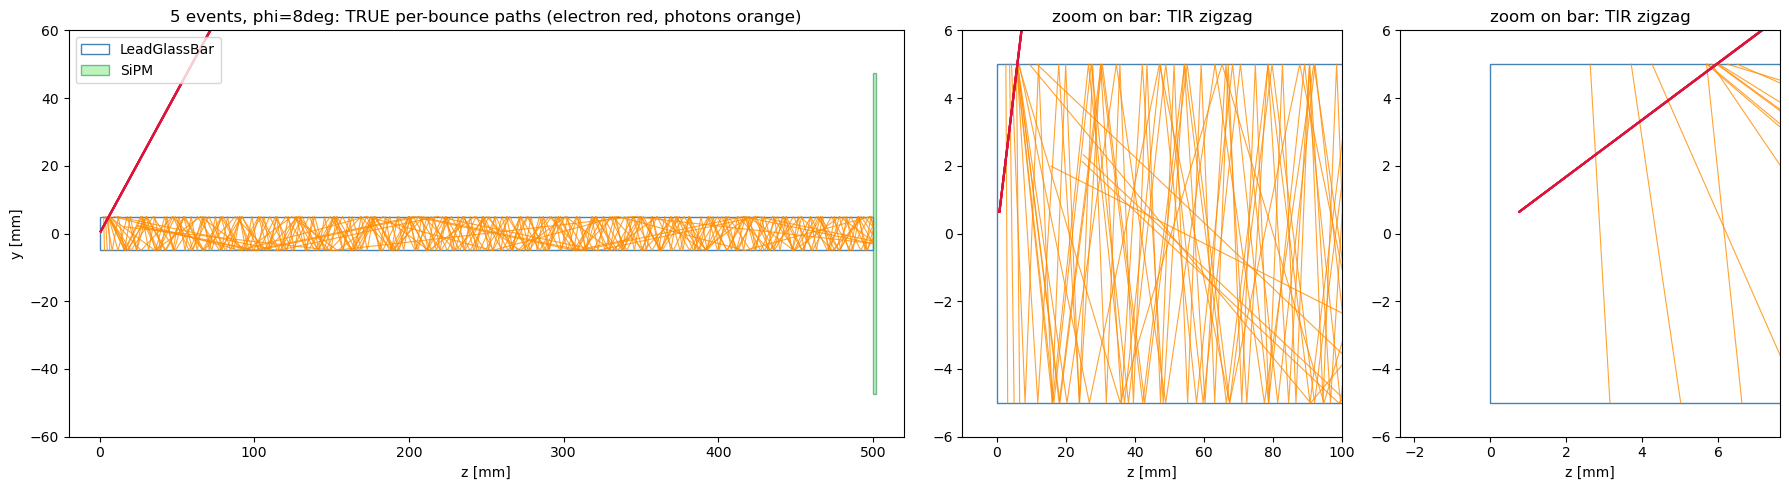

In [132]:
fig, (ax, ax_zoom, ax_zoom2) = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={'width_ratios': [2.2, 1, 1]})

for a in (ax, ax_zoom, ax_zoom2):
    a.add_patch(plt.Rectangle((BAR_Z0, -BAR_HALF_Y), BAR_Z1 - BAR_Z0, 2 * BAR_HALF_Y,
                               facecolor='none', edgecolor='steelblue', label='LeadGlassBar'))
    for line in photon_polylines:
        a.plot(line[:, 2], line[:, 1], color='darkorange', alpha=0.8, linewidth=0.8)
    for line in electron_polylines:
        a.plot(line[:, 2], line[:, 1], color='crimson', linewidth=1.5)

ax.add_patch(plt.Rectangle((SIPM_Z0, -SIPM_HALF_Y), SIPM_Z1 - SIPM_Z0, 2 * SIPM_HALF_Y,
                            facecolor='lightgreen', edgecolor='seagreen', alpha=0.6, label='SiPM'))
ax.set_xlabel('z [mm]')
ax.set_ylabel('y [mm]')
ax.set_xlim(-20, Z_VIEW_MAX)
ax.set_ylim(-60, 60)
ax.legend(loc='upper left')
ax.set_title(f'{N_EVENTS_STEPS} events, phi=8deg: TRUE per-bounce paths (electron red, photons orange)')

ax_zoom.set_xlabel('z [mm]')
ax_zoom.set_xlim(-10, 100)
ax_zoom.set_ylim(-BAR_HALF_Y - 1, BAR_HALF_Y + 1)
ax_zoom.set_title('zoom on bar: TIR zigzag')

ax_zoom2.set_xlabel('z [mm]')
ax_zoom2.set_xlim(np.min(Z0) - BAR_HALF_Y, np.min(Z0) + BAR_HALF_Y)
ax_zoom2.set_ylim(-BAR_HALF_Y - 1, BAR_HALF_Y + 1)
ax_zoom2.set_title('zoom on bar: TIR zigzag')

fig.tight_layout()

Text(0.5, 0.92, '5 events, phi=8deg: TRUE per-bounce paths')

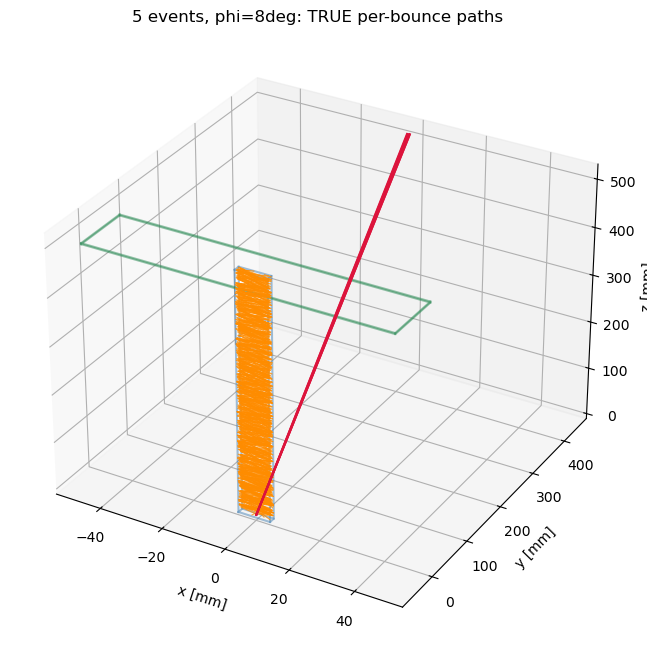

In [133]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

_plot_box(ax, BAR_HALF_X, BAR_HALF_Y, BAR_Z0, BAR_Z1, 'steelblue')
_plot_box(ax, SIPM_HALF_X, SIPM_HALF_Y, SIPM_Z0, SIPM_Z1, 'seagreen')

for line in photon_polylines:
    ax.plot(line[:, 0], line[:, 1], line[:, 2], color='darkorange', alpha=0.8, linewidth=0.8)

for line in electron_polylines:
    ax.plot(line[:, 0], line[:, 1], line[:, 2], color='crimson', linewidth=1.5)

ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
ax.set_zlabel('z [mm]')
ax.set_title(f'{N_EVENTS_STEPS} events, phi=8deg: TRUE per-bounce paths')

# Local emission angle

In [134]:
from math import acos, pi

n_leadGlass = 1.47
acos(1/(n_leadGlass)) / pi * 180

47.13508975092565

In [135]:
# Measured Cherenkov emission angle: for each photon, compare its momentum
# at birth against the PRIMARY ELECTRON's own momentum at that same z (from
# its true per-step hits, nearest in z) -- not the fixed gun direction --
# so the comparison stays valid even where the electron has scattered a bit.
mx_s, my_s, mz_s = (mcp_s[f'MCParticles.momentum.{c}'].array() for c in 'xyz')
vx_s, vy_s, vz_s = (mcp_s[f'MCParticles.vertex.{c}'].array() for c in 'xyz')
lgb_s_mx, lgb_s_my, lgb_s_mz = (lgb_s[f'LeadGlassBarHits.momentum.{c}'].array() for c in 'xyz')


def _unit(v):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    n[n == 0] = 1
    return v / n

emission_angles = []

for i in range(N_EVENTS_STEPS):
    p = ak.to_numpy(pdg_s[i])
    primary_mask = (ak.to_numpy(pbeg_s[i]) == ak.to_numpy(pend_s[i])) & (ak.to_numpy(gstat_s[i]) == 1)
    e_idx = np.nonzero(primary_mask)[0][0]

    idx = ak.to_numpy(lgb_s_idx[i])
    em = idx == e_idx
    e_z = ak.to_numpy(lgb_s_z[i])[em]
    e_mom = np.stack([ak.to_numpy(lgb_s_mx[i])[em], ak.to_numpy(lgb_s_my[i])[em], ak.to_numpy(lgb_s_mz[i])[em]], axis=-1)
    if len(e_z) < 2:
        continue
    order = np.argsort(e_z)
    e_z, e_mom = e_z[order], e_mom[order]

    ph_idx = np.nonzero(p == -22)[0]
    ph_vz = ak.to_numpy(vz_s[i])[ph_idx]
    ph_mom = np.stack([ak.to_numpy(mx_s[i])[ph_idx], ak.to_numpy(my_s[i])[ph_idx], ak.to_numpy(mz_s[i])[ph_idx]], axis=-1)

    # only compare photons emitted within the z-range the electron actually
    # has hits in, so "nearest" doesn't extrapolate past the tracked region
    in_range = (ph_vz >= e_z.min()) & (ph_vz <= e_z.max())
    ph_vz, ph_mom = ph_vz[in_range], ph_mom[in_range]
    if len(ph_vz) == 0:
        continue

    nearest = np.clip(np.searchsorted(e_z, ph_vz), 0, len(e_z) - 1)
    cos_ang = np.clip(np.sum(_unit(e_mom[nearest]) * _unit(ph_mom), axis=-1), -1, 1)
    emission_angles.append(np.degrees(np.arccos(cos_ang)))

emission_angles = np.concatenate(emission_angles)
theta_c = np.degrees(acos(1 / n_leadGlass))

print(f'n photons compared: {len(emission_angles)}')
print(f'measured: median={np.median(emission_angles):.2f}deg  mean={emission_angles.mean():.2f}deg  std={emission_angles.std():.2f}deg')
print(f'theory:   arccos(1/{n_leadGlass}) = {theta_c:.2f}deg')

n photons compared: 1182
measured: median=47.13deg  mean=47.20deg  std=4.18deg
theory:   arccos(1/1.47) = 47.14deg


Text(0.5, 1.0, 'Cherenkov emission angle, n=1.47 (1182 photons, 5 events)')

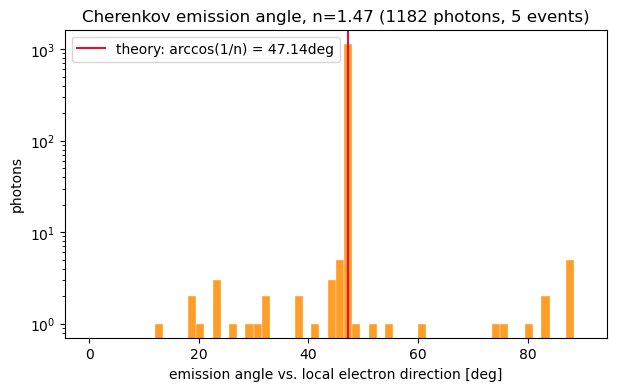

In [136]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(emission_angles, bins=60, range=(0, 90), color='darkorange', alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(theta_c, color='crimson', linewidth=1.5, label=f'theory: arccos(1/n) = {theta_c:.2f}deg')
ax.set_xlabel('emission angle vs. local electron direction [deg]')
ax.set_ylabel('photons')
ax.set_yscale('log')
ax.legend()
ax.set_title(f'Cherenkov emission angle, n={n_leadGlass} ({len(emission_angles)} photons, {N_EVENTS_STEPS} events)')